# Part 1: Problem Framing, EDA and Preprocessing Pipeline
**Course:** Introduction to Machine Learning
**Group:** 5
**Members:** Urooj Fatima Muddsar, Aayla Zahid, Fatima Naveed
**Dataset:** Adult Census Income (Kaggle)

## 1. Problem Statement
- **Task:** Binary classification
- **Target:** `income` (`<=50K` or `>50K`)
- **Goal:** Predict whether a person earns more than 50K per year from demographic and work features.
- **Success metric:** F1-score (main) and ROC-AUC (supporting). Only about 24% of the people earn more than 50K, so the classes are imbalanced. A model that always predicts "<=50K" would already get about 76% accuracy without learning anything, so accuracy alone is misleading. F1-score balances precision and recall for the minority class (>50K), and ROC-AUC shows how well the model separates the two classes at all thresholds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Data
In this dataset missing values are written as `?`, so we convert them to NaN while loading.

In [2]:
df = pd.read_csv("../data/adult.csv", na_values="?", skipinitialspace=True)
print(df.shape)
df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [4]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 3. Missing Values and Duplicates

In [5]:
missing = df.isna().sum()
print(missing[missing > 0])
print("Missing %:")
print((df.isna().mean() * 100).round(2)[missing > 0])
print("Duplicate rows:", df.duplicated().sum())

workclass         1836
occupation        1843
native.country     583
dtype: int64
Missing %:


workclass         5.64
occupation        5.66
native.country    1.79
dtype: float64
Duplicate rows: 24


## 4. Exploratory Data Analysis (EDA)

### Visual 1: Target distribution (class imbalance)

income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


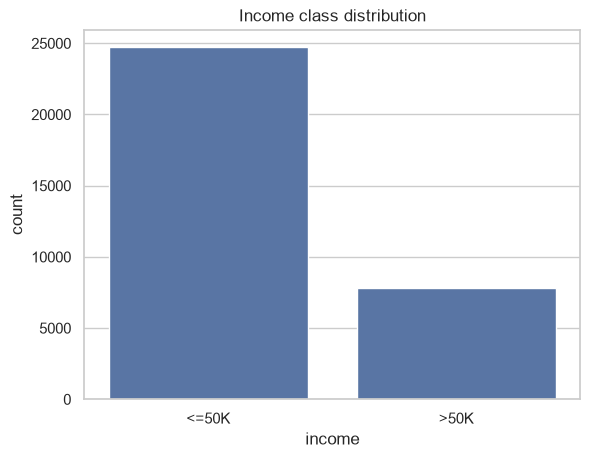

In [6]:
print(df["income"].value_counts(normalize=True).round(3))
sns.countplot(data=df, x="income")
plt.title("Income class distribution")
plt.show()

### Visual 2: Age and hours per week vs income

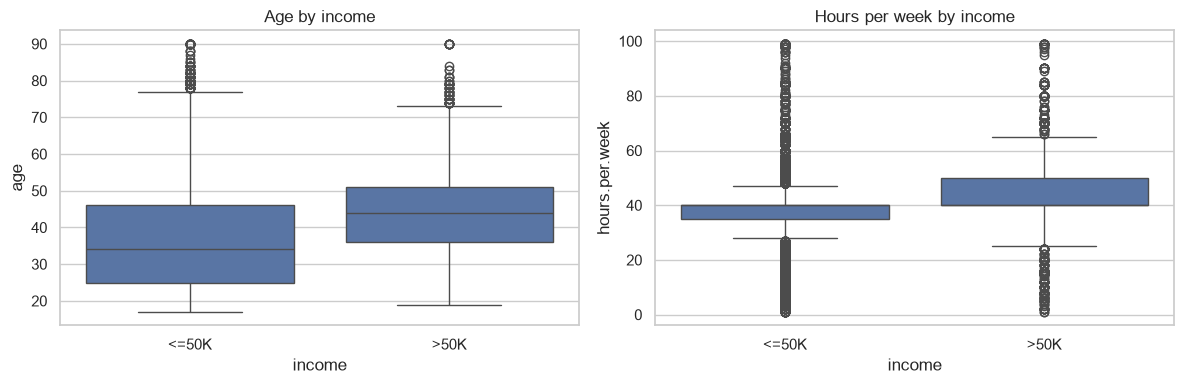

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="income", y="age", ax=axes[0])
axes[0].set_title("Age by income")
sns.boxplot(data=df, x="income", y="hours.per.week", ax=axes[1])
axes[1].set_title("Hours per week by income")
plt.tight_layout()
plt.show()

### Visual 3: Education level and sex vs income

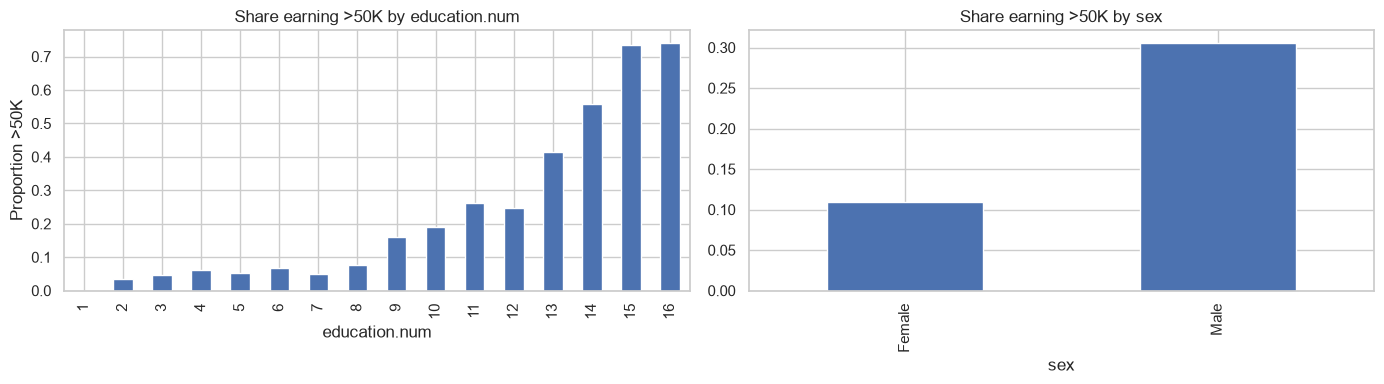

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
edu = df.groupby("education.num")["income"].apply(lambda s: (s == ">50K").mean())
edu.plot(kind="bar", ax=axes[0])
axes[0].set_title("Share earning >50K by education.num")
axes[0].set_ylabel("Proportion >50K")
sex = df.groupby("sex")["income"].apply(lambda s: (s == ">50K").mean())
sex.plot(kind="bar", ax=axes[1])
axes[1].set_title("Share earning >50K by sex")
plt.tight_layout()
plt.show()

### Visual 4 (extra): Missing values and skewed numeric columns

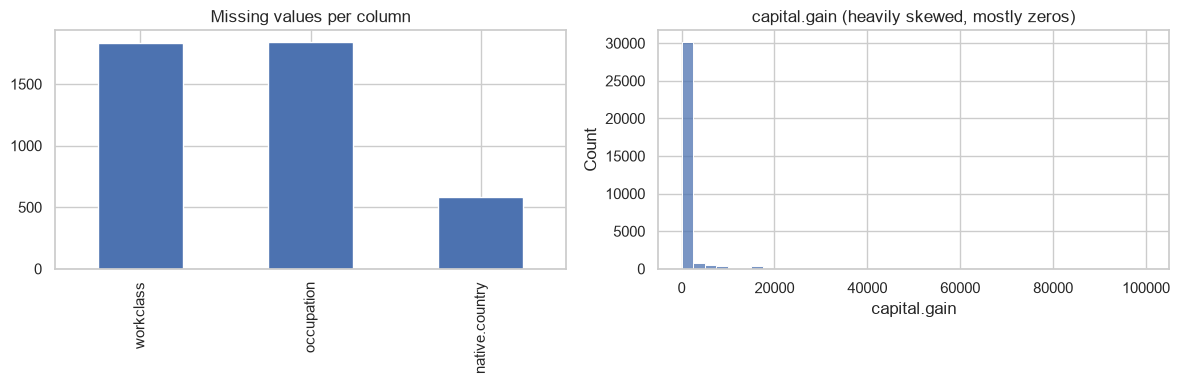

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.isna().sum()[lambda s: s > 0].plot(kind="bar", ax=axes[0])
axes[0].set_title("Missing values per column")
sns.histplot(df["capital.gain"], bins=40, ax=axes[1])
axes[1].set_title("capital.gain (heavily skewed, mostly zeros)")
plt.tight_layout()
plt.show()

### EDA Observations

1. **Class imbalance:** About 76% of the records are "<=50K" and 24% are ">50K". Accuracy alone will be misleading, so we use F1-score and ROC-AUC, and we use a stratified split.
2. **Missing values:** Missing values (originally marked "?") appear only in three categorical columns: workclass (~5.6%), occupation (~5.7%) and native.country (~1.8%). There are no missing values in numeric columns. We impute them inside the pipeline using the most frequent value.
3. **Skewed numeric features:** capital.gain is zero for about 92% of people and capital.loss is zero for about 95%. A small number of people have very large values (capital.gain goes up to 99,999), so these columns have strong outliers and are heavily skewed.
4. **Age:** People who earn >50K are older. The median age is 44 for the >50K group and 34 for the <=50K group.
5. **Hours per week:** The median is 40 hours for both groups, so hours alone does not separate the classes strongly.
6. **Education:** Higher education is strongly linked with higher income. The share of >50K earners rises from under 20% for people with 9 to 10 years of education to above 70% for those with 15 to 16 years.
7. **Sex:** About 31% of men earn >50K compared to about 11% of women. This shows a bias in the data, which we will discuss in the fairness section in Part 4.
8. **Duplicates:** There are 24 duplicate rows, which is very few compared to the total of 32,561 rows.

## Outlier Analysis
We check outliers with the IQR rule (values beyond 1.5 x IQR from the quartiles). This is only an analysis step, the actual handling is done inside the pipeline (Section 6).

In [10]:
num_check = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
rows = []
for c in num_check:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < low) | (df[c] > high)).sum()
    rows.append([c, n_out, round(100 * n_out / len(df), 2)])
pd.DataFrame(rows, columns=["column", "outliers (IQR rule)", "% of rows"])

,column,outliers (IQR rule),% of rows
0,age,143,0.44
1,education.num,1198,3.68
2,capital.gain,2712,8.33
3,capital.loss,1519,4.67
4,hours.per.week,9008,27.66


**Outlier handling decision:** capital.gain and capital.loss are extremely skewed (most values are 0, a few are very large, capital.gain goes up to 99,999). We reduce this skew with a log(1 + x) transform inside the pipeline, followed by scaling. We do not remove rows, because these large values are real information about high earners. age, education.num and hours.per.week have plausible values, so we only scale them.

## 5. Train/Test Split (before any preprocessing)
We split first and fit preprocessing on the training set only, so no information from the test set leaks into training. `stratify=y` keeps the class ratio the same in both sets.

In [11]:
y = (df["income"] == ">50K").astype(int)   # 1 = >50K, 0 = <=50K
X = df.drop(columns=["income"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print(y_train.mean().round(3), y_test.mean().round(3))

(26048, 14) (6513, 14)
0.241 0.241


### Feature Construction
We create new features from existing columns. These rules are row-by-row with fixed thresholds (nothing is learned from the data), so applying them to the train and test sets separately causes no leakage.
- has_capital_gain / has_capital_loss: 1 if the value is above 0, because most people have 0
- is_married: 1 if marital.status starts with "Married"
- age_group: age grouped into 6 fixed bands

In [12]:
def add_features(data):
    data = data.copy()
    data["has_capital_gain"] = (data["capital.gain"] > 0).astype(int)
    data["has_capital_loss"] = (data["capital.loss"] > 0).astype(int)
    data["is_married"] = data["marital.status"].str.startswith("Married").astype(int)
    data["age_group"] = pd.cut(
        data["age"], bins=[0, 25, 35, 45, 55, 65, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
    ).astype(str)
    return data

X_train = add_features(X_train)
X_test = add_features(X_test)
print(X_train.shape, X_test.shape)
X_train[["age", "age_group", "is_married", "has_capital_gain"]].head()

(26048, 18) (6513, 18)


,age,age_group,is_married,has_capital_gain
11219,34,26-35,0,0
28304,24,<=25,1,0
30810,39,36-45,1,0
10958,28,26-35,0,0
26814,56,56-65,0,0


## 6. Preprocessing Pipeline
- **Numeric columns:** median imputation, then standard scaling
- **Skewed columns (capital.gain, capital.loss):** median imputation, then log(1 + x) transform to reduce outliers, then scaling
- **Categorical columns:** most-frequent imputation, then one-hot encoding (handle_unknown="ignore")
- **Feature selection:** SelectKBest (ANOVA F-test) keeps the 40 best features. It is part of the pipeline, so the scores are computed on the training set only.

`education` is dropped because it duplicates `education.num`. `fnlwgt` is a census sampling weight and is not useful for prediction, so it is dropped too.

In [13]:
drop_cols = ["education", "fnlwgt"]
X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")

skewed_cols = ["capital.gain", "capital.loss"]
num_cols = [c for c in X_train.select_dtypes(include="number").columns if c not in skewed_cols]
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
print("Numeric:", num_cols)
print("Skewed:", skewed_cols)
print("Categorical:", cat_cols)

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
skew_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("skew", skew_pipe, skewed_cols),
    ("cat", cat_pipe, cat_cols),
])

full_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("select", SelectKBest(score_func=f_classif, k=40)),
])

Numeric: ['age', 'education.num', 'hours.per.week', 'has_capital_gain', 'has_capital_loss', 'is_married']
Skewed: ['capital.gain', 'capital.loss']
Categorical: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'age_group']


In [15]:
X_train_prep = full_pipe.fit_transform(X_train, y_train)   # fit on train only
X_test_prep = full_pipe.transform(X_test)                  # only transform on test
print("Train shape after pipeline:", X_train_prep.shape)
print("Test shape after pipeline:", X_test_prep.shape)

Train shape after pipeline: (26048, 40)
Test shape after pipeline: (6513, 40)


In [16]:
names = full_pipe.named_steps["preprocess"].get_feature_names_out()
selector = full_pipe.named_steps["select"]
print("Features before selection:", len(names), "| kept:", selector.get_support().sum())
pd.Series(selector.scores_, index=names).sort_values(ascending=False).head(10).round(1)

Features before selection: 96 | kept: 40


cat__marital.status_Married-civ-spouse    6490.2
num__is_married                           6127.8
cat__relationship_Husband                 5088.7
num__education.num                        3249.1
cat__marital.status_Never-married         2922.0
skew__capital.gain                        2412.7
num__has_capital_gain                     2014.5
cat__age_group_<=25                       1872.7
num__age                                  1489.3
num__hours.per.week                       1460.1
dtype: float64

**Feature selection result:** The pipeline created 96 features after encoding and SelectKBest kept the 40 with the highest F-scores. The top features are mostly marital status / relationship (married), education.num, capital gain and age, which matches what we saw in the EDA.

## 7. Handling Class Imbalance
Only about 24% of the records are >50K. We handle this in two ways: (1) a stratified split, so train and test keep the same 76% / 24% ratio, and (2) class weights, which make the model give more importance to the minority class (>50K) during training. We use class weights instead of oversampling (like SMOTE) because they do not create artificial rows and do not touch the test set. We evaluate with F1-score and ROC-AUC instead of accuracy.

In [18]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
print("Class weights (0 = <=50K, 1 = >50K):", dict(zip(classes, weights.round(2))))

# Quick sanity check: does the pipeline work end to end, and does class weighting help?
for cw in [None, "balanced"]:
    clf = LogisticRegression(max_iter=1000, class_weight=cw)
    clf.fit(X_train_prep, y_train)
    pred = clf.predict(X_test_prep)
    proba = clf.predict_proba(X_test_prep)[:, 1]
    print(f"class_weight={cw}: F1 = {f1_score(y_test, pred):.3f}, ROC-AUC = {roc_auc_score(y_test, proba):.3f}")

Class weights (0 = <=50K, 1 = >50K): {np.int64(0): np.float64(0.66), np.int64(1): np.float64(2.08)}
class_weight=None: F1 = 0.665, ROC-AUC = 0.906
class_weight=balanced: F1 = 0.679, ROC-AUC = 0.906


**Result:** With class_weight="balanced" the F1-score of the minority class improves (about 0.665 to 0.679 in our run) while ROC-AUC stays about the same (about 0.906). This is only a sanity check of the pipeline. The proper model comparison starts in Part 2.

## 8. Summary
In Part 1 we framed income prediction (>50K or <=50K) as a binary classification problem on the Adult Census Income dataset (32,561 rows). The EDA showed class imbalance (76% / 24%), missing values only in workclass, occupation and native.country, strong skew in capital.gain / capital.loss, and a clear link between income and education, age, marital status and sex. We split the data first (stratified 80/20) and built a leakage-free scikit-learn Pipeline: imputation, scaling, log transform for skewed columns, one-hot encoding, new features (has_capital_gain, has_capital_loss, is_married, age_group) and SelectKBest feature selection, all fitted on the training set only. Class imbalance is handled with a stratified split and class weights. The final data has 40 features and is ready for Part 2, where we will compare Naive Bayes and a decision tree using cross-validation.